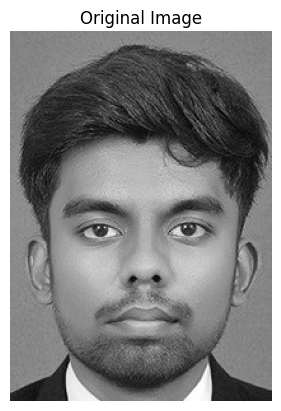

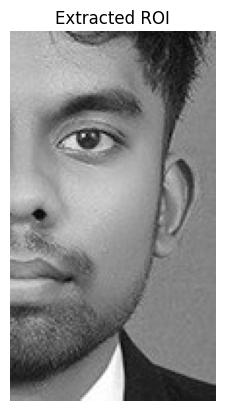

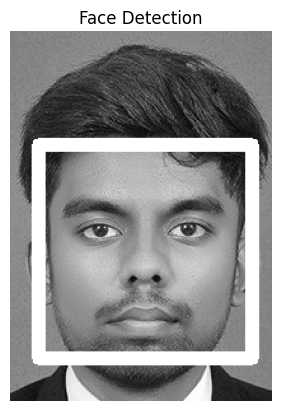

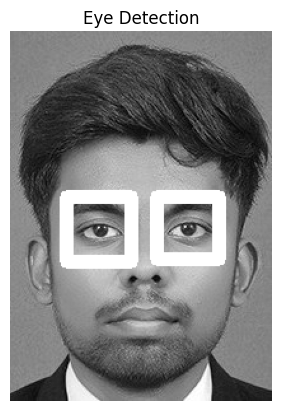

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load Image
# --------------------------------------------------

img = cv2.imread(r"C:\Users\admin\Downloads\L.jpeg", 0)

if img is None:
    print("Image not found!")
    exit()

# Display original image
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()


# --------------------------------------------------
# Extract ROI
# --------------------------------------------------

roi = img[100:400, 100:400]

plt.imshow(roi, cmap="gray")
plt.title("Extracted ROI")
plt.axis("off")
plt.show()


# --------------------------------------------------
# Load Haar Cascade Classifiers
# --------------------------------------------------

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_eye.xml"
)


# --------------------------------------------------
# Face Detection Function
# --------------------------------------------------

def detect_face(img):

    img_copy = img.copy()

    faces = face_cascade.detectMultiScale(
        img_copy,
        scaleFactor=1.3,
        minNeighbors=5
    )

    for (x, y, w, h) in faces:

        cv2.rectangle(
            img_copy,
            (x, y),
            (x + w, y + h),
            (255, 255, 255),
            10
        )

    return img_copy


# --------------------------------------------------
# Eye Detection Function
# --------------------------------------------------

def detect_eyes(img):

    img_copy = img.copy()

    eyes = eye_cascade.detectMultiScale(
        img_copy,
        scaleFactor=1.3,
        minNeighbors=5
    )

    for (x, y, w, h) in eyes:

        cv2.rectangle(
            img_copy,
            (x, y),
            (x + w, y + h),
            (255, 255, 255),
            10
        )

    return img_copy


# --------------------------------------------------
# Face Detection on Image
# --------------------------------------------------

face_result = detect_face(img)

plt.imshow(face_result, cmap="gray")
plt.title("Face Detection")
plt.axis("off")
plt.show()


# --------------------------------------------------
# Eye Detection on Image
# --------------------------------------------------

eye_result = detect_eyes(img)

plt.imshow(eye_result, cmap="gray")
plt.title("Eye Detection")
plt.axis("off")
plt.show()


# --------------------------------------------------
# Real-Time Face Detection using Webcam
# --------------------------------------------------

cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        print("Unable to access webcam")
        break

    # Convert frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5
    )

    # Draw rectangle and label
    for (x, y, w, h) in faces:

        cv2.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (255, 255, 255),
            3
        )

        cv2.putText(
            frame,
            "Face",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (255, 255, 255),
            2
        )

    # Display video
    cv2.imshow(
        "Real-Time Face Detection",
        frame
    )

    # Press ESC to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break


    


# --------------------------------------------------
# Release Resources
# --------------------------------------------------

cap.release()
cv2.destroyAllWindows()